In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt


In [2]:
# LOAD DATASET
df = pd.read_csv("student_placement_salary_elite_v2.csv")

print("Dataset shape:", df.shape)
print(df.head())

# HANDLE MISSING VALUES

df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape: (7702, 16)
   cgpa  college_tier  python_skill  dsa_skill  ml_skill  web_dev_skill  \
0  6.87             1             1          1         0              0   
1  6.52             2             1          0         0              1   
2  5.33             1             1          1         1              0   
3  6.04             3             1          0         1              0   
4  6.78             2             0          1         0              1   

   coding_score  communication_score  aptitude_score  internships  projects  \
0          15.6                  4.3            92.0            1         3   
1          13.9                  5.8            62.0            1         6   
2           9.8                  8.1            66.4            0         5   
3          39.5                  9.6            83.6            0         6   
4           7.5                  9.9            86.3            0         3   

   backlogs  resume_score  skill_score  placed  

In [3]:
# DEFINE FEATURES AND TARGET

X = df.drop(["salary_lpa", "placed"], axis=1)
y = df["salary_lpa"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7702, 14)
Target shape: (7702,)


In [4]:
# TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (5391, 14)
Validation size: (1155, 14)
Test size: (1156, 14)


In [5]:
# FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
X_test_tensor = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_val_tensor = torch.FloatTensor(y_val.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)


In [6]:
# CREATE DATALOADERS

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [7]:
# BUILD BASELINE MLP MODEL

class BaselineMLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_size = X_train.shape[1]

model = BaselineMLP(input_size)

print(model)

BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
# LOSS FUNCTION & OPTIMIZER

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [9]:
# TRAINING LOOP

epochs = 100

train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAINING

    model.train()

    running_train_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    # VALIDATION

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            val_outputs = model(batch_X)

            val_loss = criterion(val_outputs, batch_y)

            running_val_loss += val_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Validation Loss: {avg_val_loss:.4f}")

Epoch [10/100] | Train Loss: 151.5151 | Validation Loss: 170.9337
Epoch [20/100] | Train Loss: 124.4212 | Validation Loss: 143.8731
Epoch [30/100] | Train Loss: 107.2964 | Validation Loss: 126.6592
Epoch [40/100] | Train Loss: 102.3695 | Validation Loss: 124.2607
Epoch [50/100] | Train Loss: 99.1086 | Validation Loss: 121.2557
Epoch [60/100] | Train Loss: 97.1287 | Validation Loss: 121.6467
Epoch [70/100] | Train Loss: 96.9614 | Validation Loss: 120.9334
Epoch [80/100] | Train Loss: 94.8978 | Validation Loss: 122.0935
Epoch [90/100] | Train Loss: 94.2619 | Validation Loss: 121.7898
Epoch [100/100] | Train Loss: 92.8906 | Validation Loss: 123.7546


In [10]:
# EVALUATION ON TEST SET

model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)

predictions = predictions.numpy().flatten()
y_true = y_test.values

mae = mean_absolute_error(y_true, predictions)
mse = mean_squared_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print("===== TEST METRICS =====")
print(f"MAE  : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"R2   : {r2:.4f}")


===== TEST METRICS =====
MAE  : 8.4412
MSE : 116.3220
R2   : 0.5824


In [11]:
# SAMPLE PREDICTIONS

comparison = pd.DataFrame({
    "Actual Salary": y_true[:10],
    "Predicted Salary": predictions[:10]
})

print(comparison)


   Actual Salary  Predicted Salary
0          79.07         73.947166
1          49.36         44.158894
2          68.70         70.697914
3          59.41         73.998337
4          82.32         74.495110
5          63.24         73.717896
6          69.85         77.516663
7          60.82         67.590271
8          60.27         67.026276
9          57.59         71.244766


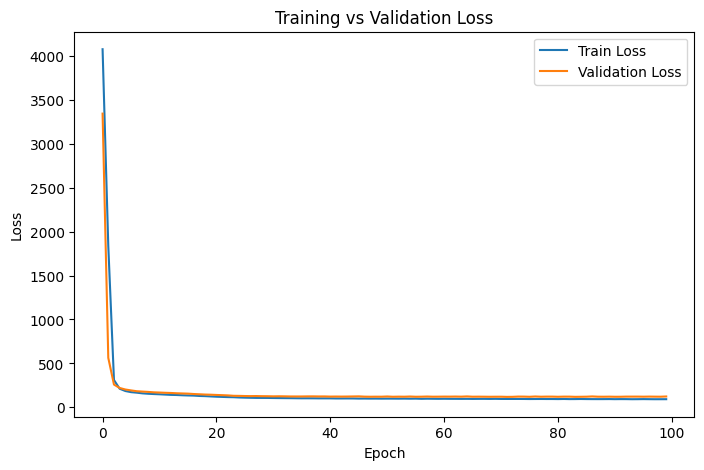

In [12]:
# VISUALIZATION

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()
